# Mini Project 2: California Real-Estate Market Regions

## 1. Setup

In [27]:
# Import the libraries used for data preparation, clustering, evaluation, and plotting.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Make results reproducible and plots consistent.
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

# Locate the mini2 project whether the notebook starts in the repository root
# or in the notebooks directory.
working_directory = Path.cwd().resolve()
if (working_directory / "mini2").is_dir():
    PROJECT_DIR = working_directory / "mini2"
else:
    PROJECT_DIR = next(
        (path for path in (working_directory, *working_directory.parents) if path.name == "mini2"),
        None,
    )

if PROJECT_DIR is None:
    raise FileNotFoundError("Run this notebook from the repository or mini2 directory.")

DATA_CACHE_DIR = PROJECT_DIR / "data" / "raw" / "sklearn"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data Acquisition

In [28]:
# Download the California Housing dataset and keep its complete data frame.
housing = fetch_california_housing(
    as_frame=True,
    data_home=DATA_CACHE_DIR,
)
df = housing.frame.copy()

# Display the dataset description and a small preview for a basic data check.
print(housing.DESCR)
display(df.head())
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Dataset shape: 20,640 rows x 9 columns


## 3. Feature Selection and Scaling

In [29]:
# Use only the three features required by the project instructions.
FEATURES = ["Longitude", "Latitude", "MedHouseVal"]
X = df.loc[:, FEATURES].copy()

# Confirm that K-means will not receive missing or non-finite values.
if X.isna().any().any() or not np.isfinite(X.to_numpy()).all():
    raise ValueError("The clustering features contain missing or non-finite values.")

# Standardize each feature so its units and numeric range do not dominate
# the Euclidean distances used by K-means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaling_check = pd.DataFrame(X_scaled, columns=FEATURES).agg(["mean", "std"])
display(scaling_check.round(3))

,Longitude,Latitude,MedHouseVal
mean,-0.0,0.0,-0.0
std,1.0,1.0,1.0


## 4. Select the Number of Clusters

In [30]:
# Compare a small, interpretable range of cluster counts. Inertia measures
# within-cluster variation, while silhouette score measures separation.
candidate_k = range(2, 11)
model_selection_rows = []

for k in candidate_k:
    candidate_model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate_model.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        candidate_labels,
        sample_size=min(5_000, len(X_scaled)),
        random_state=RANDOM_STATE,
    )
    model_selection_rows.append(
        {"k": k, "inertia": candidate_model.inertia_, "silhouette_score": score}
    )

model_selection = pd.DataFrame(model_selection_rows)
BEST_K = 4
display(model_selection.round(4))
print(f"Selected number of clusters: K = {BEST_K}")

,k,inertia,silhouette_score
0,2,26768.4222,0.5448
1,3,18289.0412,0.5288
2,4,12109.4274,0.4902
3,5,9863.6158,0.4717
4,6,8113.8660,0.4147
5,7,6563.1673,0.4096
6,8,5796.3541,0.3945
7,9,5073.3898,0.3907
8,10,4601.5192,0.3902


Selected number of clusters: K = 4


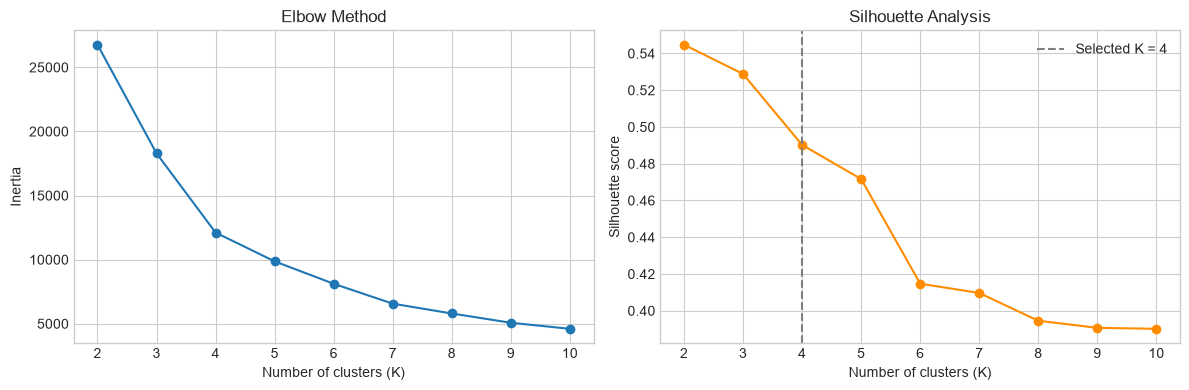

In [31]:
# Plot both diagnostics so the automatic silhouette choice can also be
# checked against the elbow in the inertia curve.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model_selection["k"], model_selection["inertia"], marker="o")
axes[0].set(title="Elbow Method", xlabel="Number of clusters (K)", ylabel="Inertia")

axes[1].plot(
    model_selection["k"],
    model_selection["silhouette_score"],
    marker="o",
    color="darkorange",
)
axes[1].axvline(BEST_K, color="gray", linestyle="--", label=f"Selected K = {BEST_K}")
axes[1].set(
    title="Silhouette Analysis",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)
axes[1].legend()

fig.tight_layout()
plt.show()

## 5. Fit the Final K-Means Model

In [32]:
# Refit K-means with the selected K and attach each observation's region label.
final_model = KMeans(
    n_clusters=BEST_K,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE,
)
df["Cluster"] = final_model.fit_predict(X_scaled) + 1
df["Region"] = "Region " + df["Cluster"].astype(str)

print(f"Final model converged in {final_model.n_iter_} iterations.")
print(f"Final inertia: {final_model.inertia_:,.2f}")

Final model converged in 21 iterations.
Final inertia: 12,109.43


## 6. Region Price Summary

In [33]:
# MedHouseVal is recorded in units of $100,000; convert it to dollars before
# reporting each region's mean house value.
region_summary = (
    df.groupby(["Cluster", "Region"], as_index=False)
    .agg(
        observations=("MedHouseVal", "size"),
        mean_longitude=("Longitude", "mean"),
        mean_latitude=("Latitude", "mean"),
        mean_house_value=("MedHouseVal", lambda values: values.mean() * 100_000),
    )
    .sort_values("Cluster")
)

region_summary_display = region_summary.copy()
region_summary_display["mean_house_value"] = region_summary_display["mean_house_value"].map(
    lambda value: f"${value:,.0f}"
)
display(region_summary_display)

,Cluster,Region,observations,mean_longitude,mean_latitude,mean_house_value
0,1,Region 1,5802,-121.440324,38.117401,"$124,204"
1,2,Region 2,9044,-117.920400,33.918421,"$163,581"
2,3,Region 3,3032,-122.135831,37.568513,"$331,013"
3,4,Region 4,2762,-118.223751,33.895196,"$385,886"


## 7. Final Map

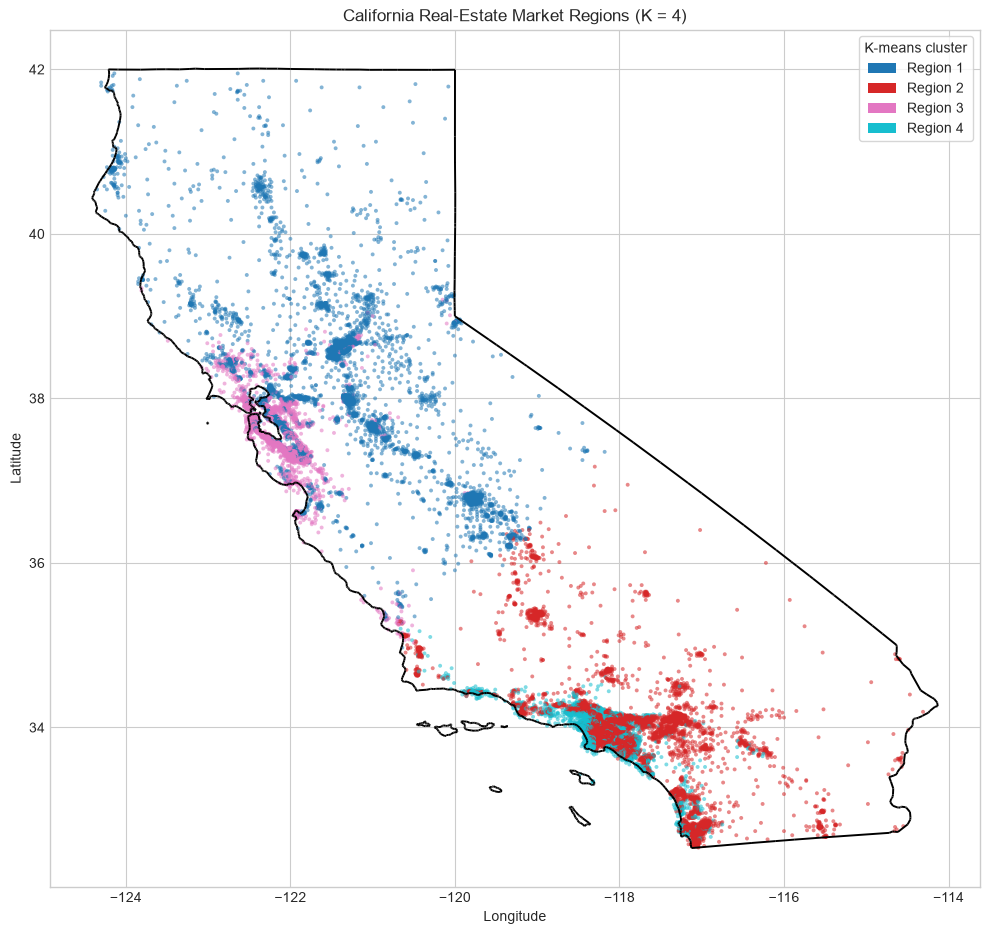

Saved final map to: C:\Users\sahil\Documents\cosmos\26-the-optimizers-analysis\mini2\results\figures\california_housing_kmeans_regions.png


In [34]:
# Load California county polygons and keep a local copy for future runs.
# Shared county edges are removed below, leaving only the California border.
import json
from collections import Counter
from matplotlib.collections import LineCollection

COUNTY_GEOJSON_PATH = PROJECT_DIR / "data" / "interim" / "ca_counties.geojson"

with COUNTY_GEOJSON_PATH.open(encoding="utf-8") as geojson_file:
    county_geojson = json.load(geojson_file)

# Count every California county-boundary segment. Segments shared by two
# counties occur twice; segments occurring once form the state border.
edge_counts = Counter()
for feature in county_geojson["features"]:
    geometry = feature["geometry"]
    polygons = (
        [geometry["coordinates"]]
        if geometry["type"] == "Polygon"
        else geometry["coordinates"]
    )
    for polygon in polygons:
        for ring in polygon:
            for start, end in zip(ring, ring[1:]):
                edge = tuple(sorted((tuple(start), tuple(end))))
                edge_counts[edge] += 1

california_border = [list(edge) for edge, count in edge_counts.items() if count == 1]

# Plot every housing observation at its geographic coordinates and color it
# by its assigned real-estate market region.
fig, ax = plt.subplots(figsize=(10, 10))
cluster_cmap = plt.get_cmap("tab10", BEST_K)
scatter = ax.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Cluster"] - 1,
    cmap=cluster_cmap,
    vmin=-0.5,
    vmax=BEST_K - 0.5,
    s=8,
    alpha=0.55,
    linewidths=0,
    zorder=2,
)

# Draw the California state border over the clustered observations.
border_collection = LineCollection(
    california_border,
    colors="black",
    linewidths=1.4,
    zorder=3,
)
ax.add_collection(border_collection)

legend_handles = [
    Patch(facecolor=cluster_cmap(cluster - 1), label=f"Region {cluster}")
    for cluster in range(1, BEST_K + 1)
]
ax.legend(
    handles=legend_handles,
    title="K-means cluster",
    loc="best",
    frameon=True,
)
ax.set(
    title=f"California Real-Estate Market Regions (K = {BEST_K})",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()

# Save the required final map at publication quality.
MAP_PATH = FIGURES_DIR / "california_housing_kmeans_regions.png"
fig.savefig(MAP_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved final map to: {MAP_PATH}")